In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from utils.funciones_minio import crear_cliente_minio, bajar_minio, bajar_mapa_minio, buscar_todos_los_archivos, contar_imagenes_por_clase, filtrar_filas_con_imagen, remover_filas_sin_imagen_minio
from utils.config import PATH_PRIMARIOS_LIMPIO, MINIO_PRIMARIOS_IMAGENES, MINIO_PRIMARIOS_IMAGENES_ALQUILER, MINIO_PRIMARIOS_IMAGENES_VENTA

Clase: Banyo
Tamaño: (1500, 1125)
Modo: RGB


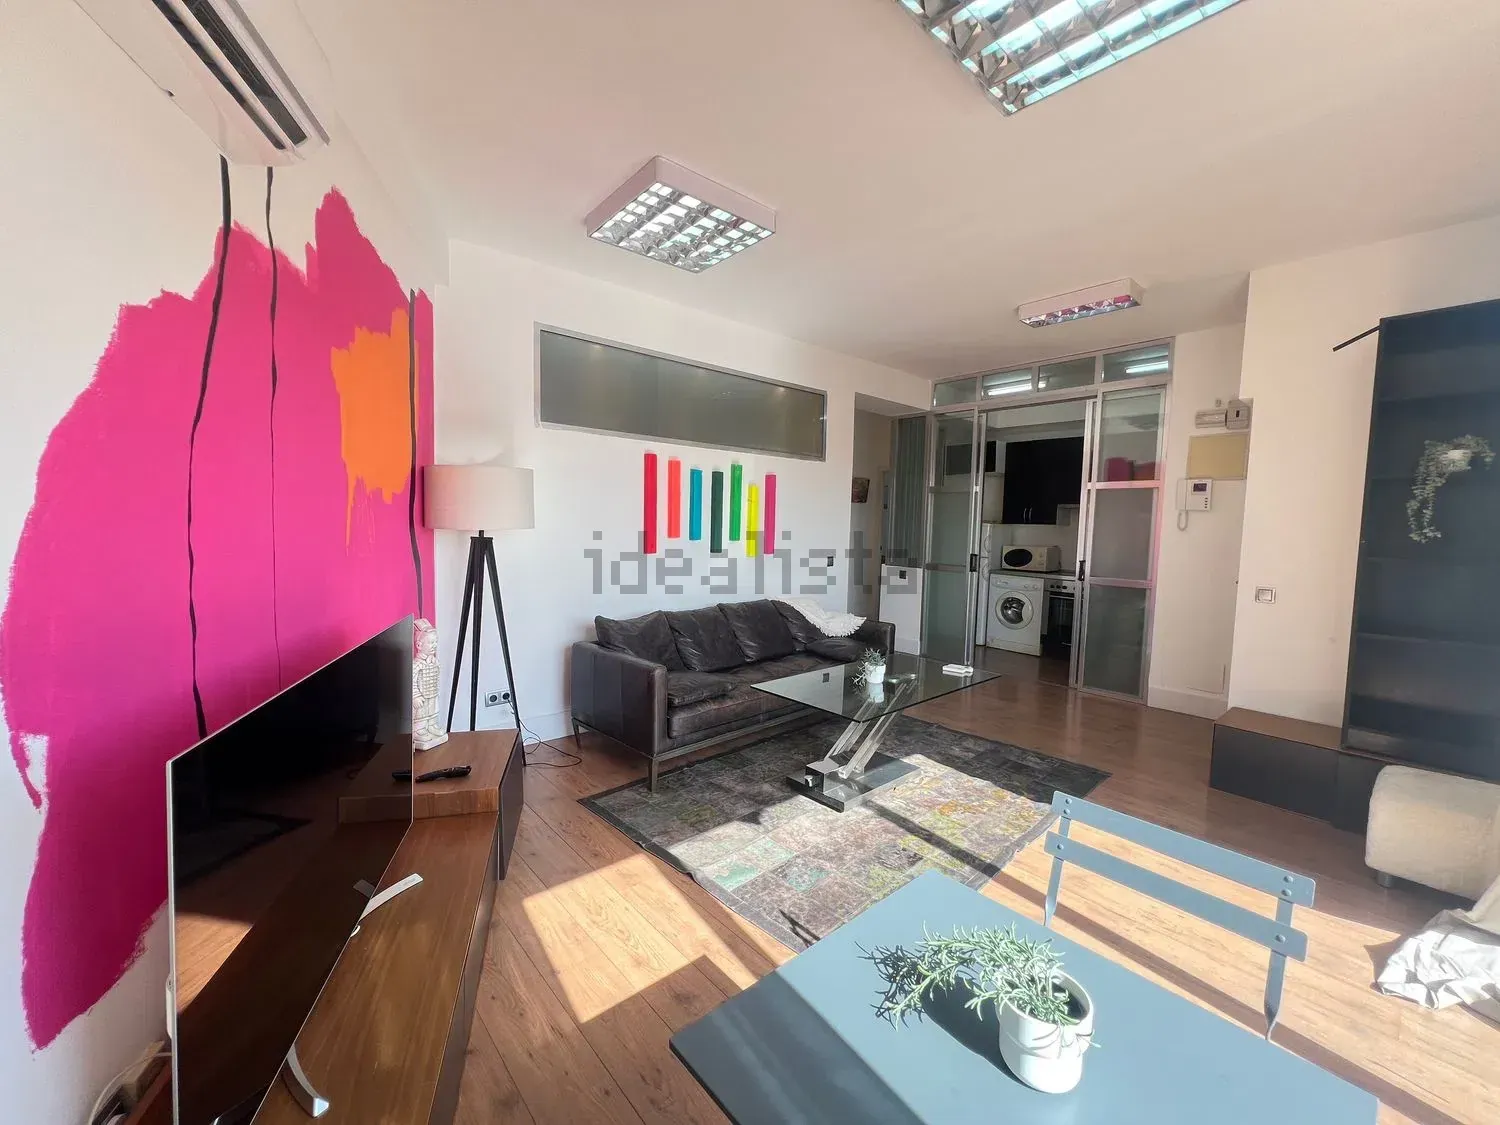

In [4]:
import pandas as pd
import io
from PIL import Image
from IPython.display import display

cliente = crear_cliente_minio()
ruta_alquiler = MINIO_PRIMARIOS_IMAGENES_ALQUILER
ruta_venta = MINIO_PRIMARIOS_IMAGENES_VENTA

df_prueba = bajar_minio(cliente,ruta_alquiler,"imagenes_n_3.parquet")

for i in range(len(df_prueba)):
    fila = df_prueba.iloc[i]

    # buscar la primera clase que tenga imágenes
    for clase in ["Dormitorio", "Cocina", "Salón", "Comedor", "Banyo"]:
        if fila[clase] is not None and len(fila[clase]) > 0:
            bytes_img = fila[clase][0]
            break

    img = Image.open(io.BytesIO(bytes_img))

    print("Clase:", clase)
    print("Tamaño:", img.size)
    print("Modo:", img.mode)

    display(img)
    break

In [9]:
import pandas as pd

clases = ["Dormitorio", "Cocina", "Salón", "Comedor", "Banyo"]

archivos_alquiler = buscar_todos_los_archivos(cliente, ruta_alquiler)
archivos_venta = buscar_todos_los_archivos(cliente, ruta_venta)


def procesar_archivos(path, archivos, clases):
    conteo = {clase: 0 for clase in clases}

    for idx, nombre in enumerate(archivos, start=1):
        print(f"[{idx}/{len(archivos)}] Leyendo: {nombre}")
        df = bajar_minio(cliente, path, nombre)

        df_limpio = filtrar_filas_con_imagen(df, clases)
        conteo_archivo = contar_imagenes_por_clase(df_limpio, clases)

        for clase, valor in conteo_archivo.items():
            conteo[clase] += valor

    return conteo


conteo_alquiler = procesar_archivos(ruta_alquiler, archivos_alquiler, clases)
conteo_venta = procesar_archivos(ruta_venta, archivos_venta, clases)

conteo_total = {clase: conteo_alquiler.get(clase, 0) + conteo_venta.get(clase, 0) for clase in clases}

total_imagenes = sum(conteo_total.values())

print("\nDistribución del dataset (filtrado filas sin imagen):\n")
for clase, n in conteo_total.items():
    porcentaje = (n / total_imagenes * 100) if total_imagenes > 0 else 0
    print(f"{clase:10}: {n:7} imágenes ({porcentaje:5.2f}%)")

print(f"\nTotal imágenes encontradas: {total_imagenes}")


Procesando 1/51: imagenes_n_1.parquet
Procesando 2/51: imagenes_n_10.parquet
Procesando 3/51: imagenes_n_11.parquet
Procesando 4/51: imagenes_n_12.parquet
Procesando 5/51: imagenes_n_13.parquet
Procesando 6/51: imagenes_n_14.parquet
Procesando 7/51: imagenes_n_15.parquet
Procesando 8/51: imagenes_n_16.parquet
Procesando 9/51: imagenes_n_17.parquet
Procesando 10/51: imagenes_n_18.parquet
Procesando 11/51: imagenes_n_19.parquet
Procesando 12/51: imagenes_n_2.parquet
Procesando 13/51: imagenes_n_20.parquet
Procesando 14/51: imagenes_n_3.parquet
Procesando 15/51: imagenes_n_4.parquet
Procesando 16/51: imagenes_n_5.parquet
Procesando 17/51: imagenes_n_6.parquet
Procesando 18/51: imagenes_n_7.parquet
Procesando 19/51: imagenes_n_8.parquet
Procesando 20/51: imagenes_n_9.parquet
Procesando 21/51: imagenes_n_1.parquet
Procesando 22/51: imagenes_n_10.parquet
Procesando 23/51: imagenes_n_11.parquet
Procesando 24/51: imagenes_n_12.parquet
Procesando 25/51: imagenes_n_13.parquet
Procesando 26/51: i